### Alcanzando los objetivos de desarrollo sostenible. 

Un aporte desde el machine learning.
La Organización de las Naciones Unidas (ONU) adopta, el 25 de septiembre del año 2015, la Agenda 2030 para el desarrollo sostenible, cuyo fin es reducir la pobreza, garantizar acceso a la salud y educación, buscar igualdad de género y oportunidades y disminuir el impacto ambiental, entre otros propósitos. A tal efecto, define 17 objetivos de desarrollo sostenible (ODS) y 169 metas (derivadas de los diferentes ODS). Dentro del trabajo en conjunto de diferentes entes para alcanzar el cumplimiento de los objetivos de desarrollo sostenible definidos en la Agenda 2030, muchas entidades tienen como función el seguimiento y la evaluación de las políticas públicas y su impacto a nivel social. Este es el caso del Fondo de Población de las Naciones Unidas (UNFPA, por sus siglas en inglés), que, junto con instituciones públicas y haciendo uso de diferentes herramientas de participación ciudadana, busca identificar problemas y evaluar soluciones actuales, relacionando la información con los diferentes ODS. 

Uno de los procesos que requiere de un mayor esfuerzo es la interpretación y análisis de la información textual procedente de diferentes fuentes implicadas en la planeación participativa para el desarrollo a nivel territorial, ya que es una tarea que consume gran cantidad recursos y para la cual se requiere de expertos que relacionen los textos con los ODS. Este conocimiento facilitaría la toma de decisiones con base en la opinión de la población y permitiría encaminar las políticas públicas de manera más informada para el cumplimiento de la Agenda 2030.

El objetivo del proyecto es desarrollar una solución, basada en técnicas de procesamiento del lenguaje natural y machine learning, que permita clasificar automáticamente un texto según los 17 ODS, ofreciendo una forma de presentación de resultados a través de una herramienta de fácil comprensión para el usuario final.

#### A. Objetivo.

Desarrollar una solución, basada en técnicas de procesamiento de lenguaje natural y machine learning, que facilite la interpretación y análisis de información textual para la identificación de relaciones semánticas con los Objetivos de Desarrollo Sostenibles. 

#### B. Conjunto de datos. 

El conjunto de datos forma parte del proyecto “OSDG Community Dataset” (
OSDG-CD
), en su versión 2023, que contiene un total de 40.067 textos, de los cuales 3000 provienen de fuentes relacionadas con las Naciones Unidas. También contiene documentos públicos, resúmenes de artículos y reportes. La plataforma reúne investigadores, expertos en la materia y defensores de los ODS de todo el mundo para crear una fuente amplia y precisa de información textual sobre los ODS. Los voluntarios de la comunidad utilizan la plataforma para participar en ejercicios de etiquetado en los que validan la relevancia de cada texto para los ODS basándose en sus conocimientos previos. 



El objetivo principal es clasificar a partir de un texto determinar su categoria de ODS los cuales son  los siguientes:

- ODS 1 – Fin de la pobreza
- ODS 2 – Hambre cero
- ODS 3 – Salud y bienestar
- ODS 4 – Educación de calidad
- ODS 5 – Igualdad de género
- ODS 6 – Agua limpia y saneamiento
- ODS 7 – Energía asequible y no contaminante
- ODS 8 – Trabajo decente y crecimiento económico
- ODS 9 – Industria, innovación e infraestructura
- ODS 10 – Reducción de las desigualdades
- ODS 11 – Ciudades y comunidades sostenibles
- ODS 12 – Producción y consumo responsables
- ODS 13 – Acción por el clima
- ODS 14 – Vida submarina
- ODS 15 – Vida de ecosistemas terrestres
- ODS 16 – Paz, justicia e instituciones sólidas
- `ODS 17 – Alianzas para lograr los objetivos` : Cabe aclarar que este ODS no lo tendremos en cuenta ya que en el conjunto de los datos originales no tenemos ningun ejemplo clasificado como tal.

### Importación de librerías requeridas

In [4]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


import joblib 





[nltk_data] Downloading package punkt to C:\Users\Cador-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Cador-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Cador-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Carga de datos

In [5]:
data = pd.read_csv('8_Datos_textosODS.csv', sep=';')
print("------ DATOS INICIALES ------")
print(data)

------ DATOS INICIALES ------
                                                 textos  ODS
0     "Aprendizaje" y "educación" se consideran sinó...    4
1     No dejar clara la naturaleza de estos riesgos ...    6
2     Como resultado, un mayor y mejorado acceso al ...   13
3     Con el Congreso firmemente en control de la ju...   16
4     Luego, dos secciones finales analizan las impl...    5
...                                                 ...  ...
9651  Esto implica que el tiempo de las mujeres en e...    5
9652  Sin embargo, estas fallas del mercado implican...    3
9653  El hecho de hacerlo y cómo hacerlo dependerá e...    9
9654  Esto se destacó en el primer estudio de caso, ...    6
9655  Aunque existen programas para convertirse espe...    4

[9656 rows x 2 columns]


### 1. Limpieza de los datos

In [6]:
print("--Datos Nulos:")
print(data.isna().sum())
print("--Datos duplicados:")
print(data.duplicated().sum())

--Datos Nulos:
textos    0
ODS       0
dtype: int64
--Datos duplicados:
0


<div style="
background:#d3f9d8;
border-left:6px solid #27b91a;
padding:16px;
border-radius:8px;
margin:12px 0;
width:800px;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">No se realiza eliminación de nulos ni duplicados ya que no se observan en el conjunto de datos este tipo de situaciones</b><br>
</div>

### Dividimos los datos en train, test y validación:

In [7]:
train, test = train_test_split(data, test_size=0.2, random_state=142, stratify=data['ODS'])
train, train_val = train_test_split(train, test_size=0.25, random_state=142, stratify=train['ODS'])

resumen = pd.DataFrame({
    'Conjunto': ['Train', 'Validación', 'Test'],
    'Cantidad': [len(train), len(train_val), len(test)]
})
resumen['Porcentaje'] = (resumen['Cantidad'] / len(data) * 100).round(1)

resumen

,Conjunto,Cantidad,Porcentaje
0,Train,5793,60.0
1,Validación,1931,20.0
2,Test,1932,20.0


In [8]:
x_train = train["textos"]
x_val = train_val["textos"]
x_test = test["textos"]

y_train = train["ODS"]
y_val = train_val["ODS"]
y_test = test["ODS"]

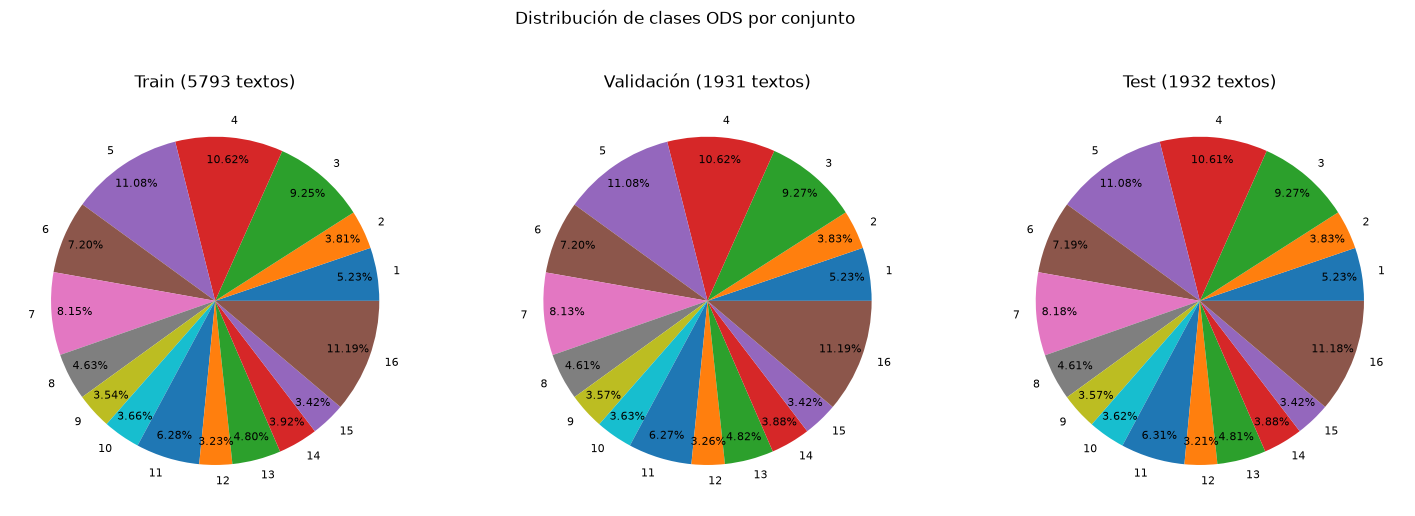

In [9]:
conjuntos = {'Train': y_train, 'Validación': y_val, 'Test': y_test}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (nombre, y) in zip(axes, conjuntos.items()):
    conteo = y.value_counts().sort_index()
    ax.pie(conteo, labels=conteo.index, autopct='%0.2f%%', pctdistance=0.86, textprops={'fontsize': 8})
    ax.set_title(f'{nombre} ({len(y)} textos)')

plt.suptitle('Distribución de clases ODS por conjunto')
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #27b91a;
padding:16px;
border-radius:8px;
margin:12px 0;
width:800px;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">Al finalizar la división en train, test y validación conseguimos una distribución de todas las clases de manera equitativa ya que se usó el parámetro stratify en el train_test_split. </b><br>
</div>

### 2. Funciones reutilizables:
Consideramos propicio en definir una serie de funciones para poder usarlas facilmente en los diferentes procesos de proyecto para mas comodidad y orden con el fin tambíen de organizar en archivos .py los diferentes componentes del proceso para un despliegue en streamlit y llamar a cada unas de las funciones dentro del streamlit_app.py.

Las funciones que creamos son las siguientes:

**Preparación de textos que van dentro del pipeline:**
- `text_preprocess()`: Definición de una función para el pipeline de procesamiento de los textos el cual realiza la conversión a minúsculas, la normalización de grados de temperatura, la tokenización de los textos, limpieza de stopwords en español y el proceso de stemming.

- `normalizar_grados()`: Unifica las distintas escrituras de grados Celsius (`2 ºC`, `2°C`, `2 grados centígrados`) en un único token `gradoscelsius`, en este caso observamos que el símbolo `ºC` aparece casi exclusivamente en textos de ODS 13 (acción por el clima) y ODS 7, por lo que es un término discriminante que queríamos conservar, no se convierte la palabra `grados` sola porque en los textos se refiere mayoritariamente a grados académicos.

- `load_processors()`: Esta función la  creamos para cargar los stopwords_spanish de español, crear el tokenizer y el stemming.
    - Acá es importante mencionar que la expresión regular `[a-záéíóúüñ][a-záéíóúüñ0-9]+`: el token debe empezar por una letra del español y puede continuar con letras o dígitos, en este caso observamos que habían muchos caracteres extraños en los datos originales como por ejemplo: `ââ,	ëoecoreââ, mundialâ, niñosâ`, además que muchos textos contienen números sueltos como fechas o porcentajes que son ruido para el modelo ya que no aportan una semántica adecuada, con este patrón se descartan esos números y símbolos, pero se conservan términos con dígitos que sí son discriminantes para ciertos ODS como `co2`, `m3`, `km2`, `kwh` o `g20` que son moleculas quimicas, medidas de longitud y/o distancia.

In [10]:


def load_processors():
    """
    El token debe empezar por una letra del español y puede continuar con letras o dígitos.
    Conserva términos como co2, m3, km2, kwh, g20 y descarta números sueltos como 2030, 15, etc.
    Los símbolos (%, º, €), caracteres basura (â, ë) y tokens de una sola letra se eliminan.
    """
    stopwords_spanish = stopwords.words('spanish')
    tokenizer = RegexpTokenizer(r'[a-záéíóúüñ][a-záéíóúüñ0-9]+')
    stemmer = SnowballStemmer('spanish')

    return stopwords_spanish, tokenizer, stemmer


stopwords_spanish, tokenizer, stemmer = load_processors()


def normalizar_grados(texto):
    """
    Unifica las distintas escrituras de grados Celsius (2 ºC, 2°C, 2 grados centígrados,
    2 grados celsius) en un único token artificial 'gradoscelsius'.
    No se toca la palabra 'grados' sola porque en el corpus suele referirse a grados académicos.
    Se aplica sobre el texto ya en minúsculas.
    """
    texto = re.sub(r'[º°]\s*c\b', ' gradoscelsius ', texto)
    texto = re.sub(r'\bgrados?\s+(?:celsius|cent[íi]grados?)\b', ' gradoscelsius ', texto)
    return texto


def text_preprocess(texto):
    
    texto = texto.lower()
    texto = normalizar_grados(texto)
    tokens = tokenizer.tokenize(texto)
    tokens = [word for word in tokens if word not in stopwords_spanish ]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)


def text_preprocess_batch(X):
    """Aplica text_preprocess a toda la columna para que lo que reciba FunctionTransformer"""
    if isinstance(X, pd.DataFrame):
        X = X.iloc[:, 0]
    return X.apply(text_preprocess)


def vectorizacion_tfidf():
    """
    Función que crea el pipeline para la bolsa de palabras con CountVectorizer
    y TfidfTransformer hace que se aplique el pesado con TF-IDF
    """
    return Pipeline([
        ("conteo", CountVectorizer()),
        ("tfidf", TfidfTransformer()),
    ])

    
def crear_pipeline_preparacion():
    """
    Arma el pipeline con todas las transformaciones de preparacion de los textos.
    Lo construimos con FunctionTransformer porque nuestras transformaciones no
    necesitan aprender nada de los datos y no es necesario hacer fit
    """
    return Pipeline([
        ("textprocess", FunctionTransformer(text_preprocess_batch)),
        ("vectorizacion_tfidf", vectorizacion_tfidf()),
    ])




### 3. Creación y aplicación del Pipeline:

In [11]:
pipeline = crear_pipeline_preparacion()
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('textprocess', ...), ('vectorizacion_tfidf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function tex...001BB0CB62200>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=No

In [12]:
X = pipeline.fit_transform(x_train)

In [13]:
X.shape   
vocab = pipeline.named_steps["vectorizacion_tfidf"].named_steps["conteo"].get_feature_names_out()
pd.DataFrame(X.toarray(), columns=vocab).head()   


,a08abaed915d3cfd0008e0,a1,a1b,a2,a7,a8,a9,aalt,aalton,aar,...,zonmw,zoolog,zou,zout30,zp,zsic,zuo,zusammenarbeit,zusatzentgelt,ñam
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4. Reducción de la dimencionalidad LSA:

En este apartado vamos a validar 45 componentes para validar la varianza y como varía en función del número de componentes para poder despues gráficar y poder elegir un número de componentes adecuado con la  interpretación cualitativa para ver si guardan relacion con los ODS del problema.

In [14]:
lsa = TruncatedSVD(n_components=45, random_state=142)
D = lsa.fit_transform(X)  


In [15]:

var_individual = lsa.explained_variance_ratio_
var_acumulada = np.cumsum(var_individual)

for k in range(10, 46):
    print(f"{k} componentes : {var_acumulada[k-1]:.2%} de varianza acumulada")

10 componentes : 5.27% de varianza acumulada
11 componentes : 5.61% de varianza acumulada
12 componentes : 5.94% de varianza acumulada
13 componentes : 6.26% de varianza acumulada
14 componentes : 6.57% de varianza acumulada
15 componentes : 6.85% de varianza acumulada
16 componentes : 7.12% de varianza acumulada
17 componentes : 7.40% de varianza acumulada
18 componentes : 7.66% de varianza acumulada
19 componentes : 7.92% de varianza acumulada
20 componentes : 8.16% de varianza acumulada
21 componentes : 8.40% de varianza acumulada
22 componentes : 8.63% de varianza acumulada
23 componentes : 8.86% de varianza acumulada
24 componentes : 9.08% de varianza acumulada
25 componentes : 9.30% de varianza acumulada
26 componentes : 9.52% de varianza acumulada
27 componentes : 9.73% de varianza acumulada
28 componentes : 9.94% de varianza acumulada
29 componentes : 10.14% de varianza acumulada
30 componentes : 10.35% de varianza acumulada
31 componentes : 10.55% de varianza acumulada
32 comp

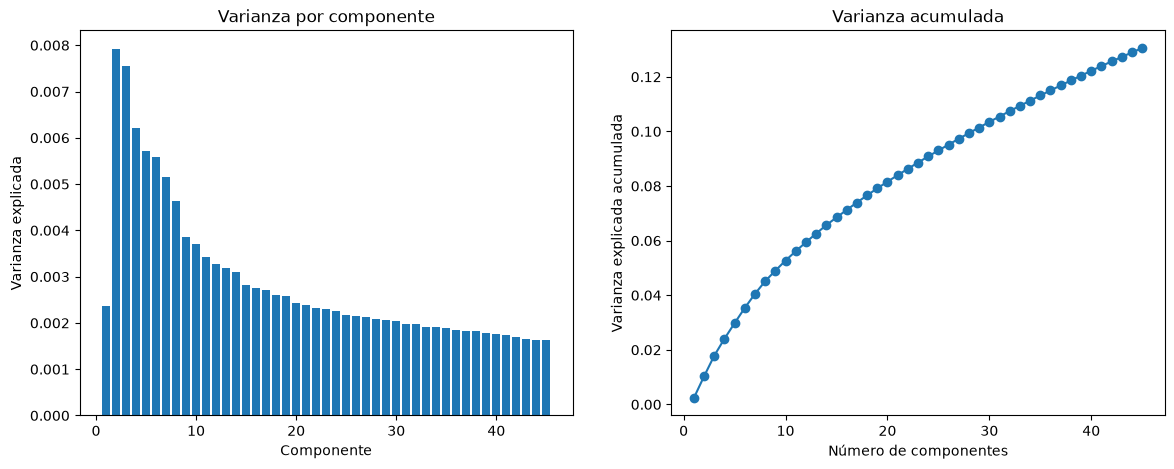

In [16]:
ks = np.arange(1, 46)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ks, var_individual)
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza por componente')

axes[1].plot(ks, var_acumulada, marker='o')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].set_title('Varianza acumulada')


plt.show()


<div style="
background:#d3f9d8;
border-left:6px solid #27b91a;
padding:16px;
border-radius:8px;
margin:12px 0;
width:800px;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">Al visualizar las gráficas resultantes por cada componentes podemos observar que la varianza comienza a tener un comportamiento lineal entre 10 y 20.

Al visualizar la varianza acumulada podemos ver que solo con 45 componentes podemos llegar a tener una varianza tan solo del 13% la cual está muy lejos de un 80% o más debido a que la matriz tiene tantas dimensiones como palabras tiene cada texto, pero en contraste con la varianza por componente es mas plausible elegir un número de componentes adecuados entre 15 y 20, pero esta desición se tomará con la interpretación de los terminos de cada tópico.
 </b><br>
</div>

In [17]:
terms = vocab
for i, comp in enumerate(lsa.components_):       # tópicos × términos
   top = comp.argsort()[::-1][:15]
   print(f"Tópico {i+1}:", " ".join(terms[j] for j in top))

Tópico 1: pais pued polit desarroll mujer agu educ gener trabaj derech mejor mayor deb aument nivel
Tópico 2: derech mujer human internacional hombr trabaj gener iguald niñ educ articul tribunal laboral violenci emple
Tópico 3: derech agu internacional human articul tribunal ley polit penal nacional gestion constitucional justici climat trat
Tópico 4: mujer agu gener hombr energ pobrez ingres derech emple iguald trabaj econom preci electr aument
Tópico 5: agu salud atencion servici mental calid educ niñ medic derech hidric person pobrez cuenc residual
Tópico 6: mujer gener agu hombr iguald educ polit particip escuel desarroll docent violenci program gestion remuner
Tópico 7: salud atencion mental servici medic pacient mujer primari sanitari segur enfermedad public calid hospital acces
Tópico 8: energ educ derech renov electr escuel energet cost estudi preci sistem eficient human docent secundari
Tópico 9: trabaj emple laboral empres sector product merc aument tiemp desemple salari remu

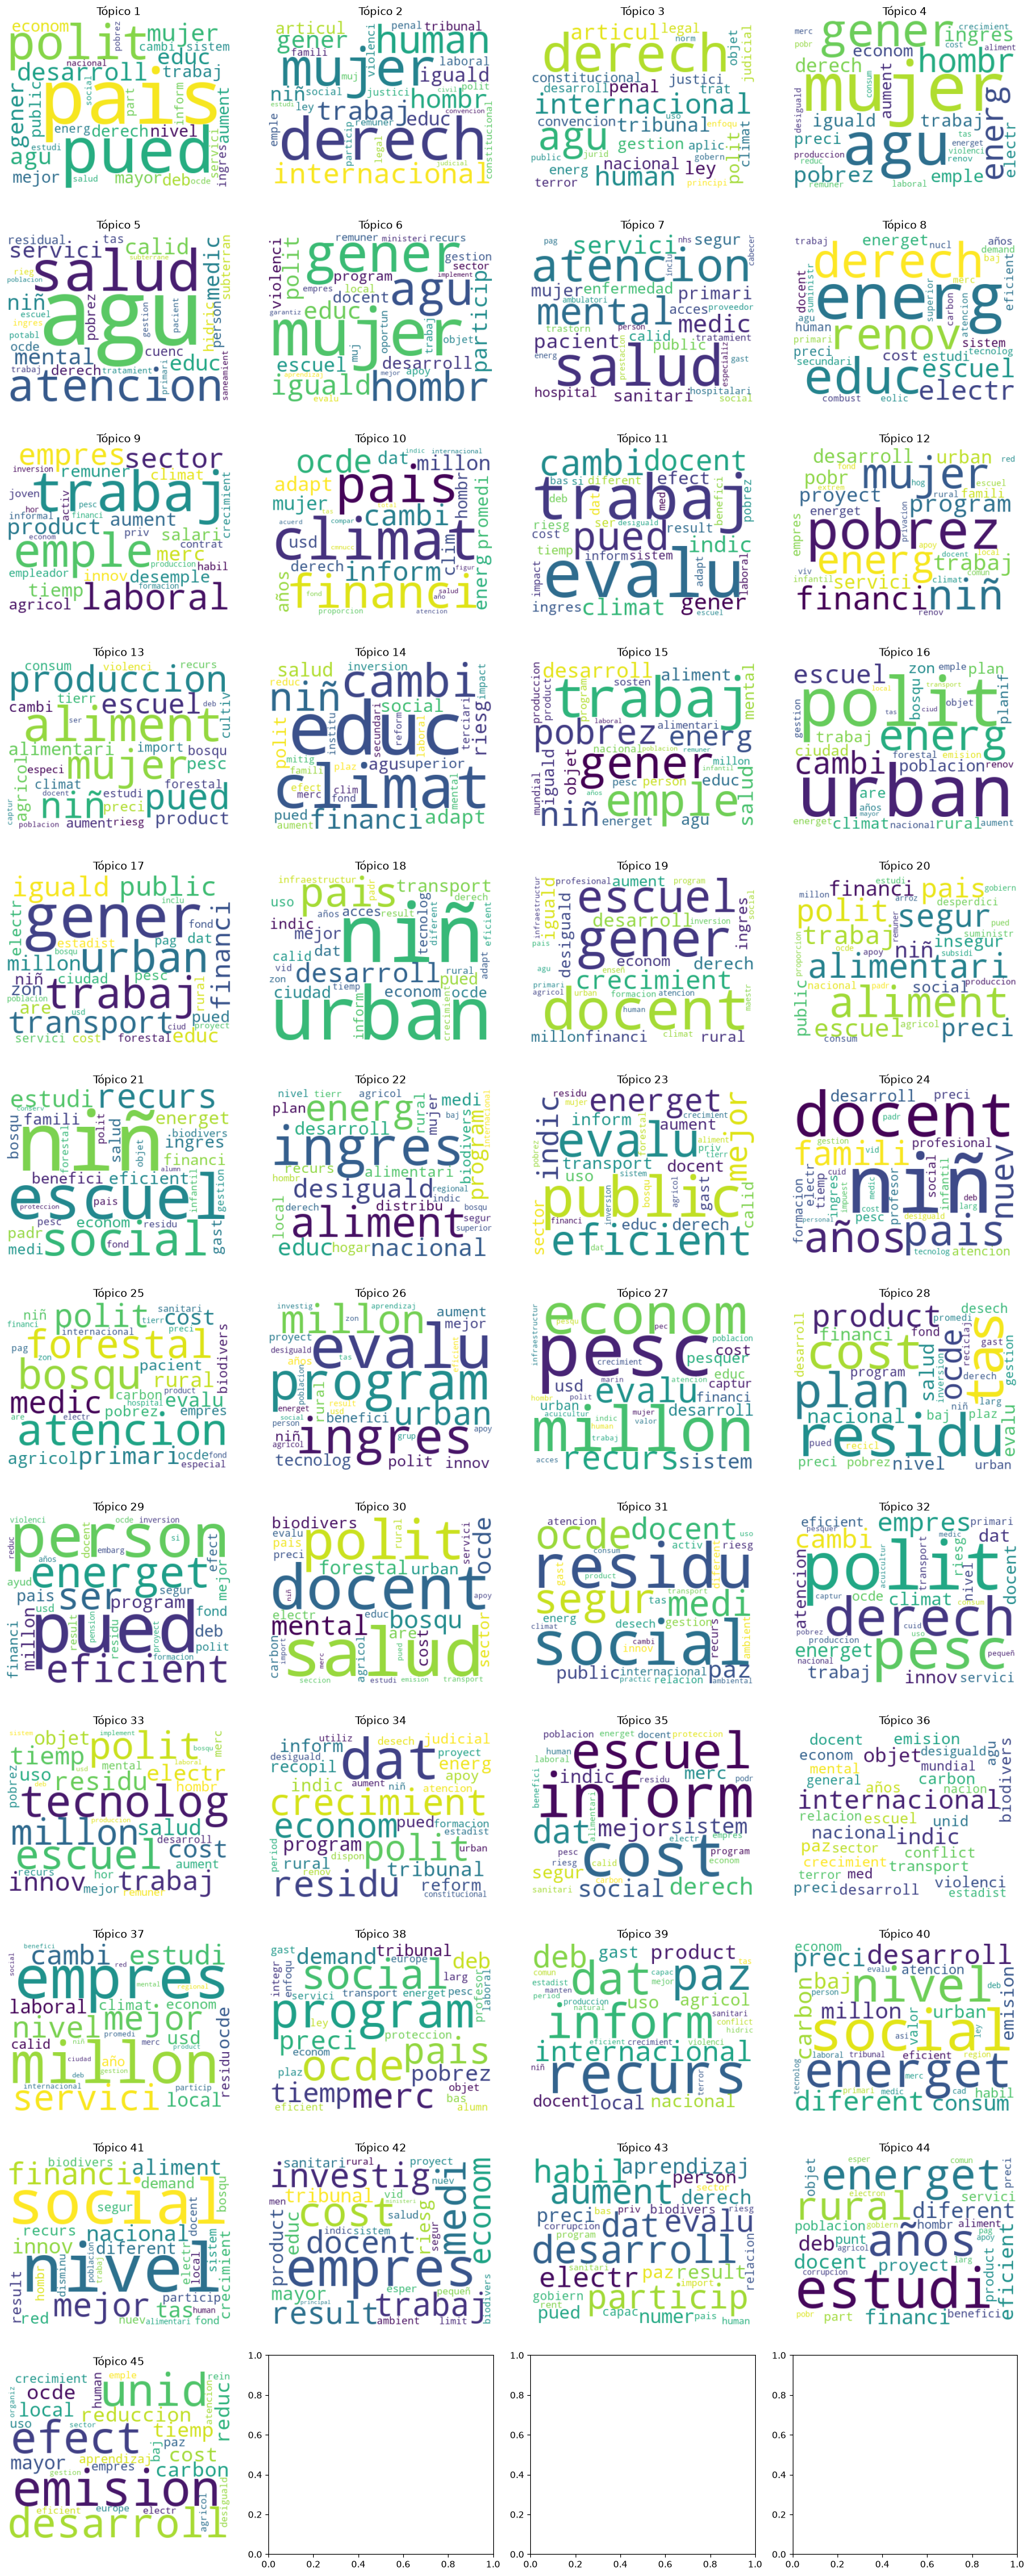

In [ ]:
def nube_componente(comp, terms, top_n=30):
    if comp[np.argmax(np.abs(comp))] < 0:   
        comp = -comp
    idx = comp.argsort()[::-1][:top_n]
    pesos = {terms[j]: comp[j] for j in idx if comp[j] > 0}
    return WordCloud(width=400, height=300, background_color='white',
                     colormap='viridis').generate_from_frequencies(pesos)

fig, axes = plt.subplots(12, 4, figsize=(16, 40))
for ax, i in zip(axes.flat, range(0, 45)):      
    ax.imshow(nube_componente(lsa.components_[i], terms), interpolation='bilinear')
    ax.set_title(f'Tópico {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()


<div style="
background:#d3f9d8;
border-left:6px solid #27b91a;
padding:16px;
border-radius:8px;
margin:12px 0;
width:1000px;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">Al observar los tópicos y realizar una interpretación cualitativa podemos identificar ciertas relaciones directas con los ODS trabajandos en el proyecto como por ejemplo:

- Tópico 5: las palabras con mayor peso (agu salud atencion servici mental calid) tienden a relacionarse muy bien con el ODS 6 Agua lipia y saneamiento.
- Tópico 7: las palabras con mayor peso (salud atencion mental servici medic pacient mujer primari) se relaciona muy bien con ODS 3 Salud y bienestar
- Tópico 12: las palabras (pobrez mujer niñ energ financi program trabaj proyect desarroll pobr) son las que tienen el mayor peso y se relacionan directamente con el ODS 1 Fin de la pobreza
- Topico 14 y 19: las palabras (educ climat cambi niñ financi adapt riesg salud social polit agu superior pued inversion docent escuel) explican muy bien el ODS 13 Accion por el clima
- Tópico 27: las palabras como (pesc econom millon captur recurs sistem) se relacionan mucho con el ODS 14 Vida submarina y el unico tópico que se puede relacionar más con dicho ODS


A partir del 27 para adelante ya es un poco más complicado poder diferenciar los tópicos con su relación mas estrecha hacia un ODS concreto y comparten varios conceptos que sugieren varios temas diferentes de ODS.
</b><br>
</div>

In [28]:
# Falta colocar entonces eh, el entrenamiento del truncate SBD con
# 300 porque toca colocar en la justificación de arriba que mmm, entre 
# 12 perdón, entre 10 y 20 no se alcanzan a explicar bien los 16 ODS por 
# lo que se necesita muchos más
# componentes para PCA perdón para el LSA



lsa = TruncatedSVD(n_components=300,algorithm='arpack', random_state=142)
D = lsa.fit_transform(X)  

ArpackError: ARPACK error -8: Error return from trid. eigenvalue calculation; Information error from LAPACK routine dsteqr.

In [ ]:
import sys
from importlib.metadata import version, PackageNotFoundError

paquetes = ["pandas", "numpy", "matplotlib", "nltk", "scikit-learn",
            "wordcloud", "joblib", "streamlit"]

print(f"Python {sys.version.split()[0]}")
for p in paquetes:
    try:
        print(f"{p}=={version(p)}")
    except PackageNotFoundError:
        print(f"{p}: no instalado")

Python 3.11.16
pandas==3.0.5
numpy==2.4.6
matplotlib==3.11.0
nltk==3.10.0
scikit-learn==1.9.0
wordcloud==1.9.6
joblib==1.5.3
streamlit==1.63.0
